In [1]:
from  langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os


In [2]:
load_dotenv()

model = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    api_key = os.getenv('GROQ_API_KEY')
)


In [22]:
# Creating State
class BLOGSTATE(TypedDict):
    topic: str
    outline: str
    blog: str
    score: float


In [4]:
def create_outline(state: BLOGSTATE) -> BLOGSTATE:

    topic = state['topic']

    prompt = f'Write a saddest Outline on the topic: {topic} for my blog'

    state['outline'] = model.invoke(prompt).content

    return state

In [5]:
def create_blog(state: BLOGSTATE) -> BLOGSTATE:

    topic = state['topic']

    outline = state['outline']

    prompt = f"""Write the saddest Blog on the following topic with its following Outline\n\n
    Topic:\n
    {topic}
    \n\n
    Outline:
    {outline}
    """

    state['blog'] = model.invoke(prompt).content

    return state

In [30]:
def evaluate_blog(state: BLOGSTATE) -> BLOGSTATE:
    prompt = f"""
    Based on the BLog Evaluate this Blog and give it score out of 10 the reponse must only the score
    \n
    Topic:
    {state['topic']}
    \n\n
    Blog:
    {state['blog']}
    \n\n
    """

    state['score'] = model.invoke(prompt).content

    return state

In [31]:
graph = StateGraph(BLOGSTATE)

# Nodes
graph.add_node('create_outline', create_outline)

graph.add_node('create_blog', create_blog)

graph.add_node('evaluate_blog', evaluate_blog)

# Edges
graph.add_edge(START, 'create_outline')

graph.add_edge('create_outline', 'create_blog')

graph.add_edge('create_blog', 'evaluate_blog')

graph.add_edge('evaluate_blog', END)


In [32]:
workflow = graph.compile()

initial_state : BLOGSTATE = {
    'topic': 'AI'
}

final_state = workflow.invoke(
    initial_state
)

print('TOPIC: ',final_state['topic'])
print()
print('Outline: ',final_state['outline'])
print()
print('BLOG: ',final_state['blog'])

print("Score: ", final_state['score'])


TOPIC:  AI

Outline:  Here's a potential outline for a blog post on the topic of AI, with a focus on the saddest aspects:

**Title:** "The Dark Side of AI: A Lament for Humanity's Future"

**I. Introduction**

* Brief overview of AI's rapid development and integration into our lives
* Thesis statement: Despite its many benefits, AI poses significant risks to human well-being, dignity, and existence

**II. Job Displacement and Economic Devastation**

* Discussion of how AI automation is replacing human workers, leading to widespread unemployment and economic instability
* Examples of industries already heavily impacted by AI-driven job displacement (e.g. manufacturing, customer service)
* Personal stories of individuals who have lost their jobs due to AI

**III. Loss of Human Connection and Empathy**

* Exploration of how AI-powered social media and virtual assistants are eroding human relationships and empathy
* Discussion of the psychological effects of excessive screen time and socia

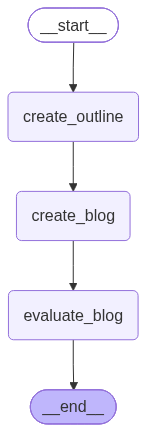

In [33]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())